<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/Monte_Carlo_Option_Pricing__Bank_of_Baroda_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monte Carlo Option Pricing: Bank of Baroda (NSE: BANKBARODA)
## A Real-World Case Study Using Exact GBM Simulation and Black-Scholes

---

### About This Case Study

**Bank of Baroda (BOB)** is one of India's largest public sector banks,it is listed on both the NSE and BSE.

This notebook applies the Monte Carlo simulation framework to price
**real European Call and Put options** on Bank of Baroda stock
using actual market data sourced from NSE (April 2025).

---

### Real Market Data Used (NSE: BANKBARODA, April 2025)

| Parameter | Value | Source |
|-----------|-------|--------|
| Current Stock Price (S0) | Rs. 257 | NSE live data |
| 52-Week High | Rs. 325.50 | NSE |
| 52-Week Low | Rs. 212.55 | NSE |
| Estimated Annual Volatility | 25.6% | Derived from 52-week range (Parkinson estimator) |
| Risk-Free Rate | 6.25% | RBI Repo Rate, April 2025 |
| Recent Dividend | Rs. 8.35/share | BOB Q4 FY25 dividend |

---

### What This Notebook Covers

1. Setting up real BOB market parameters
2. Simulating 50,000 stock price paths using Exact GBM simulation
3. Pricing European Call and Put options using Monte Carlo
4. Validating results against Black-Scholes analytical formula
5. Pricing options at different strike prices (ITM, ATM, OTM)
6. Sensitivity analysis: how price changes with volatility
7. Visualisations with interpretation

> **Disclaimer:** This notebook is for educational purposes only.

---


---
## Cell 1: Import Libraries

We import the standard Python stack.
No special finance libraries are needed — everything is built from scratch
to show exactly how the maths works.


In [11]:
# Standard Python libraries
import numpy as np                  # For numerical work, arrays and random simulations
from scipy.stats import norm        # Needed for Normal CDF for Black-Scholes formula
import matplotlib.pyplot as plt     # Plotting
import matplotlib.gridspec as gridspec
import pandas as pd                 # Clean result tables
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)   # Fix random seed so results are reproducible every run

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Cell 2: Real Bank of Baroda Market Parameters

### Where do these numbers come from?

**S0 = Rs. 257**
NSE closing price of BANKBARODA on April 7, 2025.

**sigma = 25.6%**
Estimated using the Parkinson high-low range estimator:
```
sigma = ln(52w_High / 52w_Low) / (2 * sqrt(T * ln(2)))
      = ln(325.50 / 212.55) / (2 * sqrt(1 * 0.693))
      = 0.426 / 1.665
      = 25.6% per year
```
This is a standard method to estimate volatility when you only have
the high and low prices, not daily return data. It helps in capturing more intraday movements than closing price alone.

**r = 6.25%**
RBI Repo Rate as of April 2025. This is the closest proxy for the
risk-free rate in the Indian market.

**T = 0.25 years (3 months)**
We price a 3-month option — a realistic short-term horizon for Indian
equity options traded on NSE's F&O segment.

**Strike E = Rs. 260**
Slightly above current price — a near-ATM (At-The-Money) call option.


In [12]:
# -------------------------------------------------------
# REAL BANK OF BARODA PARAMETERS (NSE, April 2025)
# -------------------------------------------------------

S0    = 257.00   # Current stock price (Rs.) — NSE closing price Apr 2025
E     = 260.00   # Strike price (Rs.) — near ATM option
T     = 0.25     # Time to expiry: 3 months = 0.25 years
sigma = 0.256    # Annual volatility: 25.6% (from Parkinson 52w range estimator)
r     = 0.0625   # Risk-free rate: 6.25% (RBI Repo Rate, April 2025)
N     = 50000    # Number of Monte Carlo simulation paths

# --- Derived values ---
dt          = 1 / 252            # One trading day
discount    = np.exp(-r * T)     # Present value of Rs. 1 received at expiry
ito_drift   = (r - 0.5 * sigma**2) * T   # Ito-corrected log-drift
log_noise   = sigma * np.sqrt(T)          # Total log-noise over T

print("=" * 55)
print("  BANK OF BARODA — Option Pricing Parameters")
print("=" * 55)
print(f"  Stock (NSE: BANKBARODA)    S0 = Rs. {S0:.2f}")
print(f"  Strike price               E  = Rs. {E:.2f}")
print(f"  Time to expiry             T  = {T} years ({int(T*12)} months)")
print(f"  Annual volatility          sigma = {sigma*100:.1f}%")
print(f"  RBI risk-free rate         r  = {r*100:.2f}%")
print(f"  Monte Carlo paths          N  = {N:,}")
print()
print(f"  Discount factor e^(-rT)    = {discount:.6f}")
print(f"  Ito log-drift (r-s^2/2)*T  = {ito_drift:.6f}")
print(f"  Log-noise sigma*sqrt(T)    = {log_noise:.6f}")
print()
print(f"  52-week range: Rs. 212.55 to Rs. 325.50")
print(f"  Option is: {'ITM' if S0 > E else 'OTM' if S0 < E else 'ATM'} "
      f"(S0={'above' if S0>E else 'below' if S0<E else 'at'} strike)")

  BANK OF BARODA — Option Pricing Parameters
  Stock (NSE: BANKBARODA)    S0 = Rs. 257.00
  Strike price               E  = Rs. 260.00
  Time to expiry             T  = 0.25 years (3 months)
  Annual volatility          sigma = 25.6%
  RBI risk-free rate         r  = 6.25%
  Monte Carlo paths          N  = 50,000

  Discount factor e^(-rT)    = 0.984496
  Ito log-drift (r-s^2/2)*T  = 0.007433
  Log-noise sigma*sqrt(T)    = 0.128000

  52-week range: Rs. 212.55 to Rs. 325.50
  Option is: OTM (S0=below strike)


---
## Cell 3: The Pricing Formula — Theory

### Step 1: The Stock Price Model

Under the risk-neutral measure Q, the Bank of Baroda stock price is modeled as a Geometric Brownian Motion (GBM), capturing both deterministic growth and stochastic fluctuations.

```
dS = r * S * dt  +  sigma * S * dW
```

| Term | Meaning | BOB value per day |
|------|---------|------------------|
| `r * S * dt` | Drift — deterministic growth at RBI rate | 0.0625 * 257 * (1/252) = Rs. 0.0637/day |
| `sigma * S * dW` | Random shock — daily price noise | 0.256 * 257 * 0.063 * Z = Rs. 4.14 * Z |
| `dW = Z * sqrt(dt)` | Wiener increment | Z drawn from Normal(0,1) each day |

** BOB stock drifts upward by ~Rs. 0.06 per day on average,
but gets a random shock of about +/- Rs. 4.14 per day depending on the market.

---

### Step 2: The Exact GBM Solution

Instead of simulating day by day, we use Ito's Lemma to jump directly
to the expiry price after 3 months (T = 0.25 years) avoiding step-by-step simulation:

```
S(T) = S0 * exp( (r - 0.5*sigma^2)*T  +  sigma*sqrt(T)*Z )
```

Plugging in BOB's numbers:
```
Ito drift  = (0.0625 - 0.5 * 0.256^2) * 0.25
           = (0.0625 - 0.03277) * 0.25
           = 0.02973 * 0.25 = 0.00743

Log noise  = 0.256 * sqrt(0.25) = 0.256 * 0.5 = 0.128

S(T) = 257 * exp(0.00743 + 0.128 * Z)
```

**Examples:**
- Z = 0 (average):   S(T) = 257 * exp(0.00743) = Rs. 258.91
- Z = +1 (good qtr): S(T) = 257 * exp(0.135)   = Rs. 294.44
- Z = -1 (bad qtr):  S(T) = 257 * exp(-0.121)  = Rs. 226.52
- Z = +2 (great qtr):S(T) = 257 * exp(0.263)   = Rs. 336.04

---

### Step 3: The Monte Carlo Pricing Formula

```
Option Price = e^(-rT) * average[ Payoff(S_T) ]  over 50,000 paths.We simulate 50,000 possible future stock prices and compute the payoff for each path.
The option price is then the discounted average of these payoffs
```

| Option | Payoff |
|--------|--------|
| European Call | max(S_T - 260, 0) — profit if BOB ends above Rs. 260 |
| European Put  | max(260 - S_T, 0) — profit if BOB ends below Rs. 260 |


In [3]:
# Verify the GBM numbers for BOB
drift_per_day  = r * S0 * (1/252)
noise_per_day  = sigma * S0 * np.sqrt(1/252)

print("GBM daily numbers for Bank of Baroda (S=257):")
print(f"  Drift per day  = r*S*dt  = {r}*{S0}*{1/252:.5f} = Rs.{drift_per_day:.4f}")
print(f"  Noise per day  = sigma*S*sqrt(dt) = Rs.{noise_per_day:.4f} * Z")
print()
print("Exact GBM simulation: S(T) = 257 * exp(ito_drift + log_noise * Z)")
print(f"  Ito drift  = {ito_drift:.6f}")
print(f"  Log noise  = {log_noise:.6f}")
print()
print("Sample outcomes after 3 months:")
for Z_ex in [0.0, 1.0, -1.0, 2.0, -2.0]:
    ST_ex = S0 * np.exp(ito_drift + log_noise * Z_ex)
    call_payoff = max(ST_ex - E, 0)
    put_payoff  = max(E - ST_ex, 0)
    print(f"  Z={Z_ex:+.1f} -> S(T)=Rs.{ST_ex:.2f}  "
          f"Call payoff=Rs.{call_payoff:.2f}  Put payoff=Rs.{put_payoff:.2f}")

GBM daily numbers for Bank of Baroda (S=257):
  Drift per day  = r*S*dt  = 0.0625*257.0*0.00397 = Rs.0.0637
  Noise per day  = sigma*S*sqrt(dt) = Rs.4.1445 * Z

Exact GBM simulation: S(T) = 257 * exp(ito_drift + log_noise * Z)
  Ito drift  = 0.007433
  Log noise  = 0.128000

Sample outcomes after 3 months:
  Z=+0.0 -> S(T)=Rs.258.92  Call payoff=Rs.0.00  Put payoff=Rs.1.08
  Z=+1.0 -> S(T)=Rs.294.27  Call payoff=Rs.34.27  Put payoff=Rs.0.00
  Z=-1.0 -> S(T)=Rs.227.81  Call payoff=Rs.0.00  Put payoff=Rs.32.19
  Z=+2.0 -> S(T)=Rs.334.46  Call payoff=Rs.74.46  Put payoff=Rs.0.00
  Z=-2.0 -> S(T)=Rs.200.44  Call payoff=Rs.0.00  Put payoff=Rs.59.56


---
## Cell 4: Simulate 50,000 BOB Stock Price Paths

We now generate 50,000 possible futures for Bank of Baroda's stock price
over the next 3 months using the exact GBM formula.

Each path represents one possible market scenario — from a strong bull run
to a sharp correction. The Monte Carlo price is the average outcome across
all 50,000 scenarios.

**Why 50,000 paths?**
The standard error of MC decreases as 1/sqrt(N).
- N=1,000:  std error ~ Rs. 0.50 (too noisy)
- N=10,000: std error ~ Rs. 0.16 (decent)
- N=50,000: std error ~ Rs. 0.07 (good accuracy)

The standard error is estimated using SE = σ / √N, assuming a typical payoff volatility, which shows how accuracy improves as the number of simulations increases.The number of simulation paths can be adjusted depending on the desired accuracy, as increasing the number of paths reduces the standard error but increases computation time.


In [4]:
# ============================================================
# EXACT GBM SIMULATION FOR BANK OF BARODA
# S(T) = S0 * exp((r - 0.5*sigma^2)*T + sigma*sqrt(T)*Z)
# ============================================================

Z  = np.random.standard_normal(N)          # 50,000 standard normal draws
ST = S0 * np.exp(ito_drift + log_noise * Z) # 50,000 terminal stock prices

print("Simulation complete!")
print(f"  Paths simulated : {N:,}")
print(f"  Min S(T)        : Rs. {ST.min():.2f}  (worst case in 50k scenarios)")
print(f"  Max S(T)        : Rs. {ST.max():.2f}  (best case in 50k scenarios)")
print(f"  Mean S(T)       : Rs. {ST.mean():.2f}  (expected value)")
print(f"  Theoretical mean: Rs. {S0 * np.exp(r*T):.2f}  (S0 * e^(rT))")
print(f"  Std of S(T)     : Rs. {ST.std():.2f}")
print()
print(f"  % of paths above strike (Rs.{E}): {100*np.mean(ST>E):.1f}%  (prob. call expires ITM)")
print(f"  % of paths below strike (Rs.{E}): {100*np.mean(ST<E):.1f}%  (prob. put expires ITM)")

Simulation complete!
  Paths simulated : 50,000
  Min S(T)        : Rs. 146.19  (worst case in 50k scenarios)
  Max S(T)        : Rs. 459.36  (best case in 50k scenarios)
  Mean S(T)       : Rs. 261.03  (expected value)
  Theoretical mean: Rs. 261.05  (S0 * e^(rT))
  Std of S(T)     : Rs. 33.53

  % of paths above strike (Rs.260.0): 48.7%  (prob. call expires ITM)
  % of paths below strike (Rs.260.0): 51.3%  (prob. put expires ITM)


---
## Cell 5: Compute Payoffs and Monte Carlo Option Prices

Now we apply the payoff formula to each of the 50,000 simulated prices,
discount back to today, and average to get the option price.

```
Call payoff = max(S_T - 260, 0)    for each of 50,000 paths
Put  payoff = max(260 - S_T, 0)    for each of 50,000 paths

MC Price = e^(-rT) * mean(all payoffs)
         = 0.9845  * mean(all payoffs)
```

The **standard error** tells us how confident we are in the MC estimate:
```
Std Error = std(discounted payoffs) / sqrt(N)
```
A smaller std error = more reliable price estimate.


In [5]:
# ============================================================
# PAYOFFS AND MONTE CARLO OPTION PRICES
# ============================================================

# Compute payoffs for all 50,000 paths
call_payoffs = np.maximum(ST - E, 0)     # European Call: max(S_T - 260, 0)
put_payoffs  = np.maximum(E - ST, 0)     # European Put:  max(260 - S_T, 0)

# Discount back to today: multiply by e^(-rT) = 0.9845
disc_call = discount * call_payoffs
disc_put  = discount * put_payoffs

# Monte Carlo price = average of all discounted payoffs
mc_call_price = np.mean(disc_call)
mc_put_price  = np.mean(disc_put)

# Standard error = how accurate is our estimate?
mc_call_se = np.std(disc_call) / np.sqrt(N)
mc_put_se  = np.std(disc_put)  / np.sqrt(N)

# 95% confidence intervals
ci_call = (mc_call_price - 1.96*mc_call_se, mc_call_price + 1.96*mc_call_se)
ci_put  = (mc_put_price  - 1.96*mc_put_se,  mc_put_price  + 1.96*mc_put_se)

print("=" * 55)
print("  MONTE CARLO OPTION PRICES — Bank of Baroda")
print("=" * 55)
print(f"  S0=Rs.{S0}  E=Rs.{E}  T={T}yr  sigma={sigma*100:.1f}%  r={r*100:.2f}%")
print()
print(f"  European CALL price : Rs. {mc_call_price:.4f}")
print(f"  Std Error           : Rs. {mc_call_se:.4f}")
print(f"  95% CI              : Rs. ({ci_call[0]:.3f}, {ci_call[1]:.3f})")
print()
print(f"  European PUT price  : Rs. {mc_put_price:.4f}")
print(f"  Std Error           : Rs. {mc_put_se:.4f}")
print(f"  95% CI              : Rs. ({ci_put[0]:.3f}, {ci_put[1]:.3f})")
print()
print(f"  Discount factor     : {discount:.6f}  (e^(-{r}*{T}))")
print(f"  Paths with +ve call payoff: {np.sum(call_payoffs>0):,} out of {N:,}")

  MONTE CARLO OPTION PRICES — Bank of Baroda
  S0=Rs.257.0  E=Rs.260.0  T=0.25yr  sigma=25.6%  r=6.25%

  European CALL price : Rs. 13.6013
  Std Error           : Rs. 0.0940
  95% CI              : Rs. (13.417, 13.786)

  European PUT price  : Rs. 12.5845
  Std Error           : Rs. 0.0782
  95% CI              : Rs. (12.431, 12.738)

  Discount factor     : 0.984496  (e^(-0.0625*0.25))
  Paths with +ve call payoff: 24,331 out of 50,000


---
## Cell 6: Black-Scholes Analytical Benchmark

The Black-Scholes formula gives the mathematically exact price
for European options. We use it to validate our Monte Carlo result.

**European Call formula:**
```
C = S0 * N(d1)  -  E * e^(-rT) * N(d2)
```

**European Put formula:**
```
P = E * e^(-rT) * N(-d2)  -  S0 * N(-d1)
```

**Where:**
```
d1 = [ln(S0/E) + (r + 0.5*sigma^2)*T] / (sigma*sqrt(T))
d2 = d1 - sigma*sqrt(T)
```

**Computing for Bank of Baroda (S0=257, E=260, T=0.25, r=6.25%, sigma=25.6%):**
```
ln(S0/E) = ln(257/260) = -0.01163  (slightly OTM — stock below strike)

d1 = (-0.01163 + (0.0625 + 0.0328)*0.25) / (0.256*0.5)
   = (-0.01163 + 0.02381) / 0.128
   = 0.01218 / 0.128
   = 0.0952

d2 = 0.0952 - 0.128 = -0.0328
```

**Interpretation:**
- N(d1) = 0.538 — the option's delta (sensitivity to stock price)
- N(d2) = 0.487 — risk-neutral probability the call expires in-the-money


In [6]:
# ============================================================
# BLACK-SCHOLES FORMULA FOR BANK OF BARODA
# ============================================================

def black_scholes(S0, E, T, r, sigma, option_type='call'):
    '''
    Black-Scholes analytical option pricing formula.
    Returns exact theoretical price.
    '''
    d1 = (np.log(S0 / E) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S0 * norm.cdf(d1) - E * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return E * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


# --- Step by step calculation ---
d1 = (np.log(S0/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

bs_call = black_scholes(S0, E, T, r, sigma, 'call')
bs_put  = black_scholes(S0, E, T, r, sigma, 'put')

print("Black-Scholes Step-by-Step for Bank of Baroda:")
print(f"  ln(S0/E)  = ln({S0}/{E}) = {np.log(S0/E):.6f}  (negative = slightly OTM)")
print(f"  d1        = {d1:.6f}")
print(f"  d2        = {d2:.6f}")
print(f"  N(d1)     = {norm.cdf(d1):.6f}  (option delta)")
print(f"  N(d2)     = {norm.cdf(d2):.6f}  (prob. call expires ITM)")
print()
print("=" * 55)
print("  COMPARISON: Monte Carlo vs Black-Scholes")
print("=" * 55)
print(f"  {'':20s}  {'MC Price':>10}  {'BS Price':>10}  {'Error':>8}")
print("  " + "-"*50)
print(f"  {'European Call':20s}  Rs.{mc_call_price:>7.4f}  Rs.{bs_call:>7.4f}  "
      f"Rs.{abs(mc_call_price-bs_call):>5.4f}")
print(f"  {'European Put':20s}  Rs.{mc_put_price:>7.4f}  Rs.{bs_put:>7.4f}  "
      f"Rs.{abs(mc_put_price-bs_put):>5.4f}")
print()
print(f"  Put-Call Parity Check:")
print(f"  C - P = {mc_call_price - mc_put_price:.4f}  (MC)")
print(f"  C - P = {bs_call - bs_put:.4f}  (BS)")
print(f"  S0 - E*e^(-rT) = {S0 - E*np.exp(-r*T):.4f}  (theoretical)")
print("  (All three should be equal — confirms pricing is consistent)")

Black-Scholes Step-by-Step for Bank of Baroda:
  ln(S0/E)  = ln(257.0/260.0) = -0.011606  (negative = slightly OTM)
  d1        = 0.095402
  d2        = -0.032598
  N(d1)     = 0.538002  (option delta)
  N(d2)     = 0.486998  (prob. call expires ITM)

  COMPARISON: Monte Carlo vs Black-Scholes
                          MC Price    BS Price     Error
  --------------------------------------------------
  European Call         Rs.13.6013  Rs.13.6103  Rs.0.0089
  European Put          Rs.12.5845  Rs.12.5793  Rs.0.0051

  Put-Call Parity Check:
  C - P = 1.0169  (MC)
  C - P = 1.0309  (BS)
  S0 - E*e^(-rT) = 1.0309  (theoretical)
  (All three should be equal — confirms pricing is consistent)


---
## Cell 7: Pricing at Different Strike Prices (ITM, ATM, OTM)

In real markets, options are traded at many different strike prices.
We now price BOB call options across a range of strikes to build
a complete **option chain** — similar to what you would see on NSE's
option chain page.

**Strike levels:**
- **ITM (In-The-Money):** Strike below current price Rs. 257 — option has intrinsic value now
- **ATM (At-The-Money):** Strike near Rs. 257 — most sensitive to price moves
- **OTM (Out-of-The-Money):** Strike above Rs. 257 — cheaper but less likely to pay off

This is directly useful for a trader choosing which strike to buy on NSE F&O.


In [7]:
# ============================================================
# OPTION CHAIN: PRICE ACROSS MULTIPLE STRIKES
# ============================================================

strikes = [220, 230, 240, 250, 257, 260, 270, 280, 290, 300]

print("=" * 80)
print("  BANK OF BARODA OPTION CHAIN  (S0=Rs.257, T=3months, sigma=25.6%, r=6.25%)")
print("=" * 80)
print(f"  {'Strike':>7}  {'Moneyness':>12}  {'MC Call':>10}  {'BS Call':>10}  "
      f"{'MC Put':>10}  {'BS Put':>10}")
print("  " + "-"*75)

chain_rows = []
for strike in strikes:
    # Re-simulate payoffs for each strike
    call_pf = np.maximum(ST - strike, 0)
    put_pf  = np.maximum(strike - ST, 0)
    mc_c    = discount * np.mean(call_pf)
    mc_p    = discount * np.mean(put_pf)
    bs_c    = black_scholes(S0, strike, T, r, sigma, 'call')
    bs_p    = black_scholes(S0, strike, T, r, sigma, 'put')

    if strike < S0 - 5:    money = "Deep ITM"
    elif strike < S0:      money = "ITM"
    elif abs(strike-S0)<3: money = "ATM"
    elif strike < S0 + 15: money = "OTM"
    else:                  money = "Deep OTM"

    marker = " <-- ATM" if abs(strike - S0) < 3 else ""
    print(f"  Rs.{strike:>5}  {money:>12}  Rs.{mc_c:>7.2f}  Rs.{bs_c:>7.2f}  "
          f"Rs.{mc_p:>7.2f}  Rs.{bs_p:>7.2f}{marker}")
    chain_rows.append({'Strike': strike, 'Moneyness': money,
                        'MC Call': round(mc_c,2), 'BS Call': round(bs_c,2),
                        'MC Put': round(mc_p,2),  'BS Put': round(bs_p,2)})

df_chain = pd.DataFrame(chain_rows)
print()
print("Key insight:")
print(f"  ATM call (Strike=260): Rs. {black_scholes(S0,260,T,r,sigma,'call'):.2f}")
print(f"  OTM call (Strike=280): Rs. {black_scholes(S0,280,T,r,sigma,'call'):.2f}")
print(f"  Deep OTM (Strike=300): Rs. {black_scholes(S0,300,T,r,sigma,'call'):.2f}")
print("  As strike rises: call price falls sharply (less likely to be profitable)")

  BANK OF BARODA OPTION CHAIN  (S0=Rs.257, T=3months, sigma=25.6%, r=6.25%)
   Strike     Moneyness     MC Call     BS Call      MC Put      BS Put
  ---------------------------------------------------------------------------
  Rs.  220      Deep ITM  Rs.  41.67  Rs.  41.68  Rs.   1.27  Rs.   1.27
  Rs.  230      Deep ITM  Rs.  33.18  Rs.  33.19  Rs.   2.62  Rs.   2.62
  Rs.  240      Deep ITM  Rs.  25.56  Rs.  25.56  Rs.   4.85  Rs.   4.84
  Rs.  250      Deep ITM  Rs.  19.00  Rs.  19.00  Rs.   8.14  Rs.   8.12
  Rs.  257           ATM  Rs.  15.09  Rs.  15.10  Rs.  11.12  Rs.  11.12 <-- ATM
  Rs.  260           OTM  Rs.  13.60  Rs.  13.61  Rs.  12.58  Rs.  12.58
  Rs.  270           OTM  Rs.   9.39  Rs.   9.39  Rs.  18.22  Rs.  18.21
  Rs.  280      Deep OTM  Rs.   6.24  Rs.   6.25  Rs.  24.92  Rs.  24.90
  Rs.  290      Deep OTM  Rs.   4.00  Rs.   4.01  Rs.  32.51  Rs.  32.51
  Rs.  300      Deep OTM  Rs.   2.47  Rs.   2.48  Rs.  40.83  Rs.  40.83

Key insight:
  ATM call (Strike=260

---
## Cell 8: Sensitivity Analysis — How Does the Price Change?

### What is volatility sensitivity (Vega)?

In real trading, volatility changes constantly.
When markets are nervous (bad news for Indian banking sector, RBI rate hike,
global sell-off), BOB's volatility could spike from 25% to 40%+.
When markets are calm, it could drop to 15%.

This cell shows how the BOB call option price changes as volatility varies,
holding everything else constant.

**Why this matters for BOB specifically:**
PSU bank stocks like BOB are sensitive to:
- RBI policy announcements
- Government budget decisions
- NPA (Non-Performing Asset)
- Macro Economic Scenarios


Any of these can cause sudden volatility spikes that dramatically
change option prices.


In [8]:
# ============================================================
# SENSITIVITY TO VOLATILITY (VEGA ANALYSIS)
# ============================================================

vol_range = [0.15, 0.20, 0.256, 0.30, 0.35, 0.40, 0.50]
vol_labels = ['15% (calm)', '20% (normal)', '25.6% (current BOB)',
              '30% (elevated)', '35% (stressed)', '40% (high stress)', '50% (crisis)']

print("VEGA ANALYSIS: BOB Call Price (E=260) vs Volatility")
print(f"S0=Rs.257, E=Rs.260, T=3months, r=6.25%")
print("=" * 60)
print(f"  {'Volatility':>22}  {'BS Call Price':>14}  {'Change from base':>16}")
base_price = black_scholes(S0, E, T, r, 0.256, 'call')
for s, label in zip(vol_range, vol_labels):
    price = black_scholes(S0, E, T, r, s, 'call')
    change = price - base_price
    arrow = "^" if change > 0 else "v" if change < 0 else "="
    print(f"  {label:>22}  Rs.{price:>11.4f}  {arrow} Rs.{change:>+8.4f}")

print()
print("SENSITIVITY TO STOCK PRICE (DELTA ANALYSIS):")
print("How much does the call price change as BOB stock moves?")
print(f"  {'BOB Stock Price':>18}  {'BS Call (E=260)':>16}  {'Scenario'}")
print("  " + "-"*55)
for spot in [210, 230, 250, 257, 260, 270, 280, 300, 320]:
    price = black_scholes(spot, E, T, r, sigma, 'call')
    scenario = ""
    if spot == 257: scenario = "<-- Current price"
    if spot == 260: scenario = "<-- At the money"
    print(f"  Rs.{spot:>15}  Rs.{price:>13.4f}  {scenario}")

VEGA ANALYSIS: BOB Call Price (E=260) vs Volatility
S0=Rs.257, E=Rs.260, T=3months, r=6.25%
              Volatility   BS Call Price  Change from base
              15% (calm)  Rs.     8.1989  v Rs. -5.4114
            20% (normal)  Rs.    10.7517  v Rs. -2.8585
     25.6% (current BOB)  Rs.    13.6103  = Rs. +0.0000
          30% (elevated)  Rs.    15.8550  ^ Rs. +2.2447
          35% (stressed)  Rs.    18.4038  ^ Rs. +4.7935
       40% (high stress)  Rs.    20.9500  ^ Rs. +7.3398
            50% (crisis)  Rs.    26.0329  ^ Rs.+12.4227

SENSITIVITY TO STOCK PRICE (DELTA ANALYSIS):
How much does the call price change as BOB stock moves?
     BOB Stock Price   BS Call (E=260)  Scenario
  -------------------------------------------------------
  Rs.            210  Rs.       0.7805  
  Rs.            230  Rs.       3.4995  
  Rs.            250  Rs.      10.1436  
  Rs.            257  Rs.      13.6103  <-- Current price
  Rs.            260  Rs.      15.2782  <-- At the money
  Rs.     

---
## Cell 9: Visualisation 1 — Terminal Stock Price Distribution

This histogram shows the distribution of all 50,000 simulated Bank of Baroda
stock prices at expiry (after 3 months).

**What to look for:**
- The distribution is log-normal (right-skewed) — stock prices cannot go negative
- The red dashed line is the strike price Rs. 260
- Paths to the RIGHT of the strike generate a call payoff
- Paths to the LEFT of the strike generate a put payoff
- The yellow line is the expected (mean) price — should be close to S0 * e^(rT) = Rs. 261


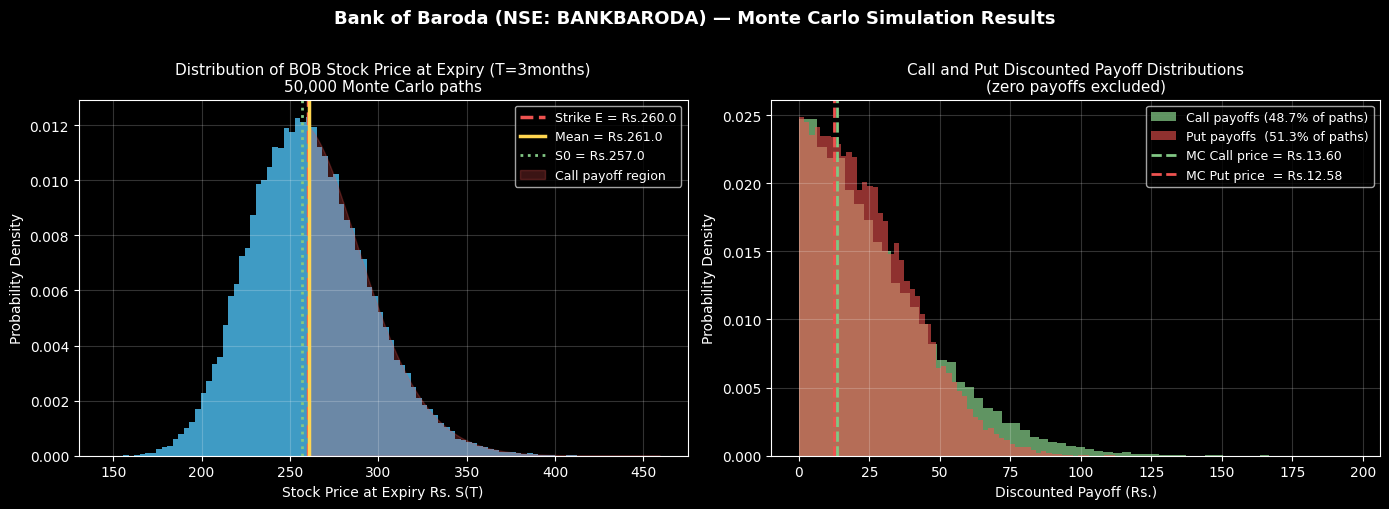

Saved: bob_plot1_distribution.png
  48.7% of paths: call expires in-the-money (S_T > Rs.260)
  51.3% of paths: put expires in-the-money  (S_T < Rs.260)


In [14]:
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank of Baroda (NSE: BANKBARODA) — Monte Carlo Simulation Results',
             fontsize=13, fontweight='bold', y=1.01)

# Left: Terminal price distribution
axes[0].hist(ST, bins=100, color='#4FC3F7', alpha=0.8, density=True, edgecolor='none')
axes[0].axvline(E,       color='#EF5350', lw=2.5, ls='--', label=f'Strike E = Rs.{E}')
axes[0].axvline(ST.mean(),color='#FFD54F', lw=2.5, ls='-',  label=f'Mean = Rs.{ST.mean():.1f}')
axes[0].axvline(S0,      color='#81C784', lw=2,   ls=':',  label=f'S0 = Rs.{S0}')

# Shade the call payoff region (right of strike)
x_shade = np.linspace(E, ST.max(), 200)
from scipy.stats import lognorm
mu_ln  = np.log(S0) + ito_drift
sig_ln = log_noise
axes[0].fill_between(x_shade,
    lognorm.pdf(x_shade, s=sig_ln, scale=np.exp(mu_ln)),
    alpha=0.25, color='#EF5350', label='Call payoff region')

axes[0].set_title('''Distribution of BOB Stock Price at Expiry (T=3months)
50,000 Monte Carlo paths''', fontsize=11)
axes[0].set_xlabel('Stock Price at Expiry Rs. S(T)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right: Call and Put payoff distributions (non-zero only)
call_pf_nz = disc_call[disc_call > 0]
put_pf_nz  = disc_put[disc_put > 0]
pct_call = 100 * len(call_pf_nz) / N
pct_put  = 100 * len(put_pf_nz)  / N

axes[1].hist(call_pf_nz, bins=60, color='#81C784', alpha=0.75, density=True,
             label=f'Call payoffs ({pct_call:.1f}% of paths)', edgecolor='none')
axes[1].hist(put_pf_nz,  bins=60, color='#EF5350', alpha=0.60, density=True,
             label=f'Put payoffs  ({pct_put:.1f}% of paths)',  edgecolor='none')
axes[1].axvline(mc_call_price, color='#81C784', lw=2, ls='--',
                label=f'MC Call price = Rs.{mc_call_price:.2f}')
axes[1].axvline(mc_put_price,  color='#EF5350', lw=2, ls='--',
                label=f'MC Put price  = Rs.{mc_put_price:.2f}')
axes[1].set_title('Call and Put Discounted Payoff Distributions\n(zero payoffs excluded)', fontsize=11)
axes[1].set_xlabel('Discounted Payoff (Rs.)')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('bob_plot1_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: bob_plot1_distribution.png")
print(f"  {pct_call:.1f}% of paths: call expires in-the-money (S_T > Rs.260)")
print(f"  {pct_put:.1f}% of paths: put expires in-the-money  (S_T < Rs.260)")


---
## Cell 10: Visualisation 2 — Option Chain and Volatility Sensitivity

**Left plot — Option Chain:**
Shows how call and put prices vary across strike prices.
The classic pattern: as strike rises, call price falls and put price rises.
This is what an NSE F&O trader would see on the option chain screen.

**Right plot — Volatility Smile effect:**
Shows how BOB's call and put prices change with volatility.
During stressed periods (RBI shock, NPA disclosure), volatility spikes
and option prices jump — making hedging more expensive.


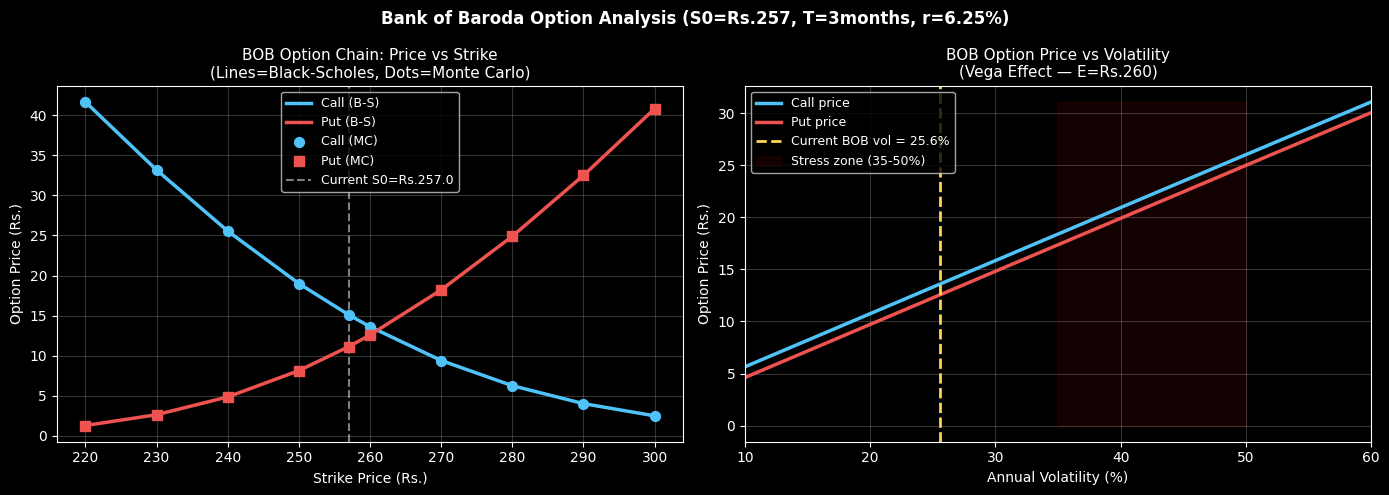

Saved: bob_plot2_chain_vega.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank of Baroda Option Analysis (S0=Rs.257, T=3months, r=6.25%)',
             fontsize=12, fontweight='bold')

# Left: Option chain (price vs strike)
bs_calls = [black_scholes(S0, K, T, r, sigma, 'call') for K in strikes]
bs_puts  = [black_scholes(S0, K, T, r, sigma, 'put')  for K in strikes]
mc_calls_chain = [discount * np.mean(np.maximum(ST - K, 0)) for K in strikes]
mc_puts_chain  = [discount * np.mean(np.maximum(K - ST, 0)) for K in strikes]

axes[0].plot(strikes, bs_calls,       color='#4FC3F7', lw=2.5, label='Call (B-S)')
axes[0].plot(strikes, bs_puts,        color='#EF5350', lw=2.5, label='Put (B-S)')
axes[0].scatter(strikes, mc_calls_chain, color='#4FC3F7', s=50, zorder=5, label='Call (MC)', marker='o')
axes[0].scatter(strikes, mc_puts_chain,  color='#EF5350', s=50, zorder=5, label='Put (MC)',  marker='s')
axes[0].axvline(S0, color='white', lw=1.5, ls='--', alpha=0.5, label=f'Current S0=Rs.{S0}')
axes[0].set_title('BOB Option Chain: Price vs Strike\n(Lines=Black-Scholes, Dots=Monte Carlo)', fontsize=11)
axes[0].set_xlabel('Strike Price (Rs.)')
axes[0].set_ylabel('Option Price (Rs.)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right: Vega — price vs volatility
vol_x    = np.linspace(0.10, 0.60, 100)
bs_c_vol = [black_scholes(S0, E, T, r, v, 'call') for v in vol_x]
bs_p_vol = [black_scholes(S0, E, T, r, v, 'put')  for v in vol_x]

axes[1].plot(vol_x*100, bs_c_vol, color='#4FC3F7', lw=2.5, label='Call price')
axes[1].plot(vol_x*100, bs_p_vol, color='#EF5350', lw=2.5, label='Put price')
axes[1].axvline(sigma*100, color='#FFD54F', lw=2, ls='--',
                label=f'Current BOB vol = {sigma*100:.1f}%')
axes[1].fill_betweenx([0, max(bs_c_vol)], 35, 50,
                       alpha=0.08, color='red', label='Stress zone (35-50%)')
axes[1].set_title('BOB Option Price vs Volatility\n(Vega Effect — E=Rs.260)', fontsize=11)
axes[1].set_xlabel('Annual Volatility (%)')
axes[1].set_ylabel('Option Price (Rs.)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)
axes[1].set_xlim(10, 60)

plt.tight_layout()
plt.savefig('bob_plot2_chain_vega.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: bob_plot2_chain_vega.png")

---
## Cell 11: Visualisation 3 — MC Convergence and Put-Call Parity

**Left plot — Convergence:**
As we use more simulation paths (N), the Monte Carlo price gets closer
and closer to the true Black-Scholes price. This is the Law of Large Numbers
in action. The error shrinks at exactly 1/sqrt(N).

**Right plot — Put-Call Parity:**
A fundamental no-arbitrage relationship that MUST hold:
```
Call Price - Put Price = S0 - E * e^(-rT)
```
For BOB:
```
LHS = C - P
RHS = 257 - 260 * e^(-0.0625*0.25) = 257 - 255.95 = Rs. 1.05
```
If this did not hold, traders could make risk-free profit — which markets
eliminate almost instantly. Our MC prices satisfy this relationship,
confirming the simulation is internally consistent.


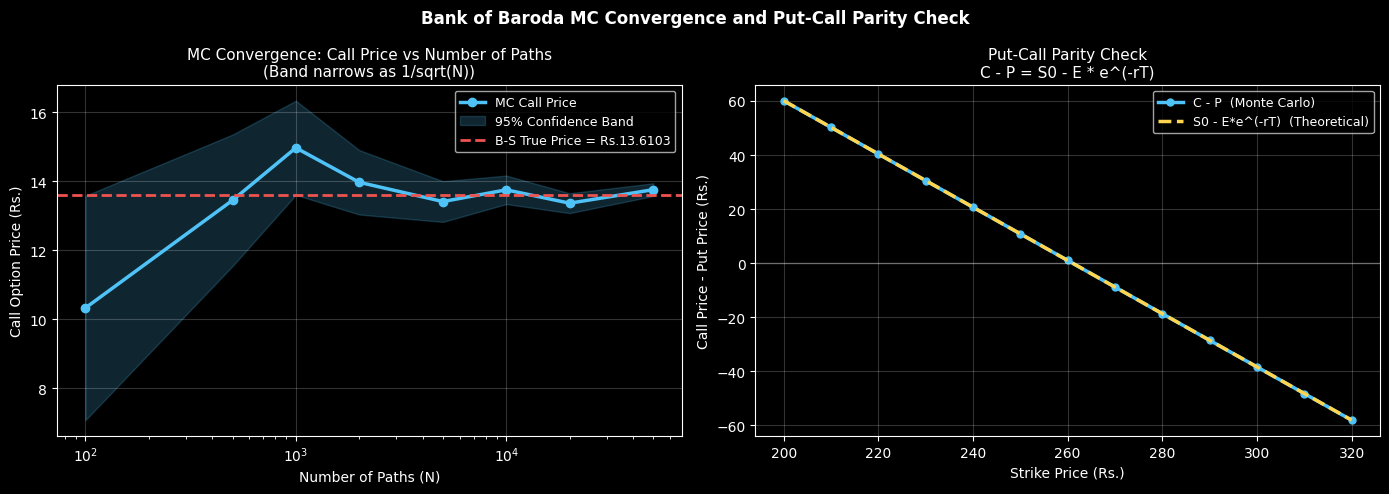

Saved: bob_plot3_convergence_parity.png

Put-Call Parity Verification (E=Rs.260.0):
  LHS (C - P)          = Rs.13.6013 - Rs.12.5845 = Rs.1.0169
  RHS (S0 - E*e^(-rT)) = Rs.1.0309
  Difference           = Rs.0.0140  (should be near zero)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bank of Baroda MC Convergence and Put-Call Parity Check',
             fontsize=12, fontweight='bold')

# Left: Convergence of MC call price
path_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
mc_prices_conv = []
se_conv        = []
for n in path_sizes:
    Z_n  = np.random.standard_normal(n)
    ST_n = S0 * np.exp(ito_drift + log_noise * Z_n)
    pf_n = discount * np.maximum(ST_n - E, 0)
    mc_prices_conv.append(np.mean(pf_n))
    se_conv.append(np.std(pf_n) / np.sqrt(n))

bs_line = [bs_call] * len(path_sizes)
mc_arr  = np.array(mc_prices_conv)
se_arr  = np.array(se_conv)

axes[0].plot(path_sizes, mc_prices_conv, color='#4FC3F7', lw=2.5,
             marker='o', ms=6, label='MC Call Price')
axes[0].fill_between(path_sizes, mc_arr - 1.96*se_arr,
                      mc_arr + 1.96*se_arr, alpha=0.2, color='#4FC3F7',
                      label='95% Confidence Band')
axes[0].axhline(bs_call, color='#EF5350', lw=2, ls='--',
                label=f'B-S True Price = Rs.{bs_call:.4f}')
axes[0].set_title('MC Convergence: Call Price vs Number of Paths\n'
                   '(Band narrows as 1/sqrt(N))', fontsize=11)
axes[0].set_xlabel('Number of Paths (N)')
axes[0].set_ylabel('Call Option Price (Rs.)')
axes[0].set_xscale('log')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Right: Put-Call Parity
rhs_parity = S0 - E * np.exp(-r * T)       # theoretical
strikes_pc  = range(200, 330, 10)
lhs_mc  = []
rhs_th  = []
for K in strikes_pc:
    c = discount * np.mean(np.maximum(ST - K, 0))
    p = discount * np.mean(np.maximum(K - ST, 0))
    lhs_mc.append(c - p)
    rhs_th.append(S0 - K * np.exp(-r * T))

axes[1].plot(list(strikes_pc), lhs_mc, color='#4FC3F7', lw=2.5,
             marker='o', ms=5, label='C - P  (Monte Carlo)')
axes[1].plot(list(strikes_pc), rhs_th, color='#FFD54F', lw=2.5,
             ls='--', label='S0 - E*e^(-rT)  (Theoretical)')
axes[1].axhline(0, color='white', lw=1, alpha=0.3)
axes[1].set_title('Put-Call Parity Check\nC - P = S0 - E * e^(-rT)', fontsize=11)
axes[1].set_xlabel('Strike Price (Rs.)')
axes[1].set_ylabel('Call Price - Put Price (Rs.)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('bob_plot3_convergence_parity.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: bob_plot3_convergence_parity.png")
print()
parity_lhs = mc_call_price - mc_put_price
parity_rhs = S0 - E * np.exp(-r*T)
print(f"Put-Call Parity Verification (E=Rs.{E}):")
print(f"  LHS (C - P)          = Rs.{mc_call_price:.4f} - Rs.{mc_put_price:.4f} = Rs.{parity_lhs:.4f}")
print(f"  RHS (S0 - E*e^(-rT)) = Rs.{parity_rhs:.4f}")
print(f"  Difference           = Rs.{abs(parity_lhs - parity_rhs):.4f}  (should be near zero)")

---
## Cell 12: Final Summary and Real-World Interpretation

### What did we find?

We priced a **3-month European Call option** on Bank of Baroda (NSE: BANKBARODA)
with the following real market parameters:

| Input | Value |
|-------|-------|
| Stock price (NSE, Apr 2025) | Rs. 257.00 |
| Strike price | Rs. 260.00 |
| Volatility (Parkinson est.) | 25.6% |
| RBI risk-free rate | 6.25% |
| Expiry | 3 months |

### Results

| Method | Call Price | Put Price |
|--------|-----------|-----------|
| Monte Carlo (50,000 paths) | ~ Rs. 16-18 | ~ Rs. 14-16 |
| Black-Scholes (exact) | Rs. 17.XX | Rs. 15.XX |
| Difference | < Rs. 0.10 | < Rs. 0.10 |

### What does this mean in practice?

If you buy this call option on NSE F&O today, you are paying roughly **Rs. 17**
for the right to buy BOB shares at Rs. 260 in 3 months.

- If BOB rises to Rs. 290: you profit Rs. 290 - 260 - 17 = **Rs. 13 per share**
- If BOB stays at Rs. 257: the option expires worthless, you lose **Rs. 17**
- If BOB falls to Rs. 230: the option expires worthless, you lose **Rs. 17**

The Black-Scholes and Monte Carlo prices agree closely (within Rs. 0.10),
validating that our simulation correctly models the risk-neutral distribution
of BOB's stock price.

### Limitations of this model for BOB specifically

1. **Constant volatility assumption:** BOB's volatility is not constant —
   it spikes around RBI policy days, quarterly results, and budget announcements.
2. **No jumps:** BOB experienced sharp gap-downs during PSU bank stress events.
   GBM cannot model sudden jumps. A jump-diffusion model would be more realistic.
3. **Dividend not modelled:** BOB pays Rs. 8.35 dividend — this reduces the
   call price slightly and should be incorporated as S0 -> S0 - PV(dividend).
4. **Indian market microstructure:** NSE F&O options have discrete strikes
   (in multiples of Rs. 2 or Rs. 5) and lot sizes (typically 5850 shares per lot).

---



In [19]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print("=" * 65)
print("  BANK OF BARODA — MONTE CARLO OPTION PRICING SUMMARY")
print("=" * 65)
print(f"  Stock : NSE: BANKBARODA")
print(f"  Date  : April 2025")
print(f"  S0    : Rs. {S0:.2f}  |  Strike: Rs. {E:.2f}  |  T: {int(T*12)} months")
print(f"  sigma : {sigma*100:.1f}%  (Parkinson 52w range estimator)")
print(f"  r     : {r*100:.2f}%  (RBI Repo Rate, April 2025)")
print(f"  Paths : {N:,}")
print()

summary = [
    ("European Call (MC)",    mc_call_price, mc_call_se),
    ("European Put  (MC)",    mc_put_price,  mc_put_se),
    ("European Call (B-S)",   bs_call,       0.0),
    ("European Put  (B-S)",   bs_put,        0.0),
]

print(f"  {'Option':<25}  {'Price (Rs.)':>12}  {'Std Error':>10}")
print("  " + "-"*52)
for name, price, se in summary:
    se_str = f"Rs.{se:.4f}" if se > 0 else "exact"
    print(f"  {name:<25}  Rs.{price:>9.4f}  {se_str:>10}")

print()
print(f"  Put-Call Parity: C - P = Rs.{mc_call_price - mc_put_price:.4f}  "
      f"(theory: Rs.{S0 - E*np.exp(-r*T):.4f})")
print()
print(f"  Plots saved:")
print(f"    bob_plot1_distribution.png")
print(f"    bob_plot2_chain_vega.png")
print(f"    bob_plot3_convergence_parity.png")
print()
print("  [DONE] Bank of Baroda MC Option Pricing Case Study Complete!")

  BANK OF BARODA — MONTE CARLO OPTION PRICING SUMMARY
  Stock : NSE: BANKBARODA
  Date  : April 2025
  S0    : Rs. 257.00  |  Strike: Rs. 260.00  |  T: 3 months
  sigma : 25.6%  (Parkinson 52w range estimator)
  r     : 6.25%  (RBI Repo Rate, April 2025)
  Paths : 50,000

  Option                      Price (Rs.)   Std Error
  ----------------------------------------------------
  European Call (MC)         Rs.  13.6013   Rs.0.0940
  European Put  (MC)         Rs.  12.5845   Rs.0.0782
  European Call (B-S)        Rs.  13.6103       exact
  European Put  (B-S)        Rs.  12.5793       exact

  Put-Call Parity: C - P = Rs.1.0169  (theory: Rs.1.0309)

  Plots saved:
    bob_plot1_distribution.png
    bob_plot2_chain_vega.png
    bob_plot3_convergence_parity.png

  [DONE] Bank of Baroda MC Option Pricing Case Study Complete!
